# Fine-tune DeReC on DRAGON

Train a Russian DeBERTa classifier to distinguish **grounded** from **ungrounded** RAG answers.

- Dataset: DRAGON (1200 examples = 600 grounded + 600 ungrounded)
- Base model: `deepvk/deberta-v1-base` (Russian DeBERTa v1)
- Binary classification: grounded=1, ungrounded=0

## Setup

In [2]:
# ! rm -r rag_fact_checking
# !git clone -b feature/evaluate-fact-checking https://github.com/BigMak1/rag_fact_checking.git
!git -C rag_fact_checking pull

Already up to date.


In [3]:
%%time
# %%capture

!uv pip install --system \
    accelerate==1.1.1 \
    datasets==3.1.0 \
    scikit-learn==1.5.2 \
    transformers==4.48.0 \
    sentence-transformers \
    tqdm \
    tiktoken \
    protobuf \
    einops \
    sentencepiece \
    bitsandbytes \
    huggingface_hub \
    faiss-gpu-cu12

Using Python 3.12.12 environment at: /usr
Resolved 72 packages in 666ms                                        
Prepared 9 packages in 1.55s                                             
Uninstalled 7 packages in 1.74s
Installed 9 packages in 57ms                                
 - accelerate==1.12.0
 + accelerate==1.1.1
 + bitsandbytes==0.49.2
 - datasets==4.0.0
 + datasets==3.1.0
 + faiss-gpu-cu12==1.14.1.post1
 - fsspec==2025.3.0
 + fsspec==2024.9.0
 - huggingface-hub==1.4.1
 + huggingface-hub==0.36.2
 - scikit-learn==1.6.1
 + scikit-learn==1.5.2
 - tokenizers==0.22.2
 + tokenizers==0.21.4
 - transformers==5.2.0
 + transformers==4.48.0
CPU times: user 64 ms, sys: 23.2 ms, total: 87.3 ms
Wall time: 4.84 s


In [4]:
import sys
import os
import json

import numpy as np
import torch
from datasets import load_dataset
from sklearn.metrics import roc_auc_score, roc_curve
from torch.utils.data import DataLoader
from transformers import AutoConfig, AutoModelForSequenceClassification
import matplotlib.pyplot as plt

sys.path.insert(0, "rag_fact_checking/DEREC")
from dataset_load import DatasetReader, UnifiedDataset, DATASET_CONFIGS
from main import EvidenceClassificationPipeline, generate_run_id

2026-03-15 14:42:18.542466: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773585738.975112     101 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773585739.091140     101 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773585740.243449     101 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773585740.243490     101 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773585740.243493     101 computation_placer.cc:177] computation placer alr

In [5]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

In [6]:
CLASSIFIER_MODEL_NAME = "ruDeberta"
DATASET_NAME = "DRAGON"
BATCH_SIZE = 8
LEARNING_RATE = 5e-6
EPOCH_SIZE = 10
SEED = 44

HF_DATASET_REPO = "Makson4ic/dragon-derec-dataset"
HF_MODEL_REPO = "Makson4ic/derec-dragon-ruDeberta"
HF_TOKEN = user_secrets.get_secret("HF_TOKEN")

BASE_DIR = "rag_fact_checking/DEREC"
DATASET_PATH = os.path.join(BASE_DIR, "dataset", DATASET_NAME)

run_id = generate_run_id()
save_dir = os.path.join(
    BASE_DIR,
    f"saved_models/{DATASET_NAME.lower()}_classifier/run_{run_id}"
)
os.makedirs(save_dir, exist_ok=True)
print(f"Run ID: {run_id}")
print(f"Save dir: {save_dir}")

Run ID: 20260315_144302_616bc0d6
Save dir: rag_fact_checking/DEREC/saved_models/dragon_classifier/run_20260315_144302_616bc0d6


## Load Dataset

In [7]:
# Load from HuggingFace Hub and save as local JSON for DatasetReader
ds = load_dataset(HF_DATASET_REPO)
os.makedirs(DATASET_PATH, exist_ok=True)

for split_name in ["train", "val", "test"]:
    records = list(ds[split_name])
    with open(os.path.join(DATASET_PATH, f"{split_name}.json"), "w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False)
    print(f"{split_name}: {len(records)} examples")

# Load via DatasetReader
train_data = DatasetReader.read_dataset(DATASET_NAME, DATASET_PATH, "train")
val_data = DatasetReader.read_dataset(DATASET_NAME, DATASET_PATH, "val")
test_data = DatasetReader.read_dataset(DATASET_NAME, DATASET_PATH, "test")

# Check class balance
for name, split in [("train", train_data), ("val", val_data), ("test", test_data)]:
    labels = [item["label"] for item in split]
    n_grounded = sum(labels)
    n_ungrounded = len(labels) - n_grounded
    print(f"{name}: grounded={n_grounded}, ungrounded={n_ungrounded}")

README.md:   0%|          | 0.00/721 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/7.25M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/2.00M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/12600 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/2700 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2700 [00:00<?, ? examples/s]

train: 12600 examples
val: 2700 examples
test: 2700 examples
train: grounded=6300, ungrounded=6300
val: grounded=1350, ungrounded=1350
test: grounded=1350, ungrounded=1350


In [9]:
example = train_data[0]
print(f"Claim:\n{example['claim']}\n")
print(f"Evidence:\n{example['evidence']}\n")
print(f"Label: {example['label']}")

Claim:
question: Какой регион был определён в качестве приоритетного для Дональда Трампа?
answer: Индхо-Тихоокеанский

Evidence:
Бывший советник офиса президента Украины Алексей Арестович в своем Telegram-канале заявил, что президент США Дональд Трамп хочет закончить конфликт на Украине в ближайшие дни, чтобы начать военную кампанию против Венесуэлы. 
По его словам, перемирие на Украине является лишь частью большой стратегии американского лидера в рамках глобального противостояния с Китаем. На данный момент, по словам политика, глава Белого дома подготавливает почву, чтобы США выиграли гонку на длинной дистанции у Китая и России.  
Для реализации задуманного, по мнению Арестовича, Трампу необходимо навести порядок в Западном полушарии в соответствии с доктриной Монро и перенести основные усилия в Индо-Тихоокеанский регион.  
"В планах Трампа - закончить войну в Украине в течение ближайших дней, после чего переключиться на Венесуэлу", - рассказал он. 
Бывший советник отметил, что интенс

## Initialize Pipeline

In [10]:
pipeline = EvidenceClassificationPipeline(
    dataset_name=DATASET_NAME,
    classifier_model=CLASSIFIER_MODEL_NAME,
)

Initializing pipeline for DRAGON dataset
Using device: cuda
DRAGON: skipping retriever (evidence pre-computed)
Loading classifier model: ruDeberta


tokenizer_config.json:   0%|          | 0.00/543 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/757 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

Some weights of DebertaForSequenceClassification were not initialized from the model checkpoint at deepvk/deberta-v1-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Train

In [11]:
%%time

pipeline.train(
    train_dataset=train_data,
    eval_dataset=val_data,
    batch_size=BATCH_SIZE,
    num_epochs=EPOCH_SIZE,
    learning_rate=LEARNING_RATE,
    save_dir=save_dir,
)

Epoch 1/10: 100%|██████████| 1575/1575 [23:25<00:00,  1.12it/s, loss=0.2346]



Epoch 1 Training Metrics:
accuracy: 0.9001
precision: 0.9001
recall: 0.9001
f1: 0.9001

Epoch 1 Validation Metrics:
accuracy: 0.9507
precision: 0.9530
recall: 0.9507
f1: 0.9507

Epoch 1 completed in: 0:25:09


Epoch 2/10: 100%|██████████| 1575/1575 [23:34<00:00,  1.11it/s, loss=0.1052]



Epoch 2 Training Metrics:
accuracy: 0.9644
precision: 0.9645
recall: 0.9644
f1: 0.9644

Epoch 2 Validation Metrics:
accuracy: 0.9600
precision: 0.9609
recall: 0.9600
f1: 0.9600

Epoch 2 completed in: 0:25:18


Epoch 3/10: 100%|██████████| 1575/1575 [23:34<00:00,  1.11it/s, loss=0.0747]


...


Epoch 8 Training Metrics:
accuracy: 0.9937
precision: 0.9937
recall: 0.9937
f1: 0.9937

Epoch 8 Validation Metrics:
accuracy: 0.9707
precision: 0.9708
recall: 0.9707
f1: 0.9707

Epoch 8 completed in: 0:25:16


Epoch 9/10: 100%|██████████| 1575/1575 [23:32<00:00,  1.11it/s, loss=0.0172]



Epoch 9 Training Metrics:
accuracy: 0.9947
precision: 0.9947
recall: 0.9947
f1: 0.9947

Epoch 9 Validation Metrics:
accuracy: 0.9707
precision: 0.9708
recall: 0.9707
f1: 0.9707

Epoch 9 completed in: 0:25:16


Epoch 10/10: 100%|██████████| 1575/1575 [23:33<00:00,  1.11it/s, loss=0.0131]



Epoch 10 Training Metrics:
accuracy: 0.9960
precision: 0.9960
recall: 0.9960
f1: 0.9960

Epoch 10 Validation Metrics:
accuracy: 0.9707
precision: 0.9708
recall: 0.9707
f1: 0.9707

Epoch 10 completed in: 0:25:16

Training Summary:
Best performance achieved in epoch 9:
accuracy: 0.9707
precision: 0.9708
recall: 0.9707
f1: 0.9707
CPU times: user 4h 5min 28s, sys: 7min 35s, total: 4h 13min 4s
Wall time: 4h 12min 43s


## Evaluate on Test Set

In [ ]:
# Load best checkpoint
best_model_path = os.path.join(save_dir, f"epoch_{pipeline.best_epoch}")
config = AutoConfig.from_pretrained(best_model_path, local_files_only=True)
pipeline.classifier = AutoModelForSequenceClassification.from_pretrained(
    best_model_path,
    config=config,
    local_files_only=True,
    trust_remote_code=True,
).to(pipeline.device)
print(f"Loaded best model from epoch {pipeline.best_epoch}")

# Prepare test data
test_claims, test_evidences, test_labels, *_ = pipeline.process_dragon_dataset(test_data)
test_dataset = UnifiedDataset(
    test_claims, test_evidences, test_labels, DATASET_NAME, pipeline.tokenizer
)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Single inference pass: collect logits and labels
pipeline.classifier.eval()
all_logits = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs = {k: v.to(pipeline.device) for k, v in batch.items()}
        outputs = pipeline.classifier(**inputs)
        all_logits.append(outputs.logits.cpu())
        all_labels.append(inputs["labels"].cpu())

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels).numpy()
all_preds = torch.argmax(all_logits, dim=1).numpy()

# Basic metrics
test_metrics = pipeline._calculate_metrics(all_labels, all_preds)
print("\nTest set metrics:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

              precision    recall  f1-score   support

  ungrounded       0.97      0.97      0.97      1350
    grounded       0.97      0.97      0.97      1350

    accuracy                           0.97      2700
   macro avg       0.97      0.97      0.97      2700
weighted avg       0.97      0.97      0.97      2700



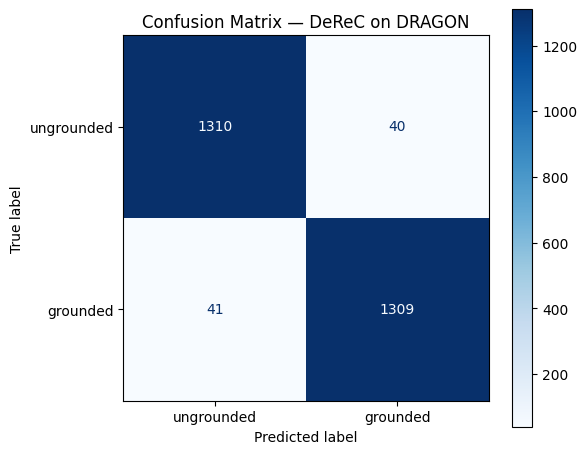

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(all_labels, all_preds, target_names=["ungrounded", "grounded"]))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["ungrounded", "grounded"]).plot(ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix — DeReC on DRAGON")
plt.tight_layout()
plt.show()

In [20]:
error_probs = torch.softmax(all_logits, dim=-1)[:, 1].numpy()

fp_idx = np.where((all_labels == 0) & (all_preds == 1))[0]
fn_idx = np.where((all_labels == 1) & (all_preds == 0))[0]

print(f"False Positives (ungrounded → predicted grounded): {len(fp_idx)}")
print(f"False Negatives (grounded → predicted ungrounded): {len(fn_idx)}")

for name, indices in [("FALSE POSITIVE", fp_idx), ("FALSE NEGATIVE", fn_idx)]:
    print(f"\n{'='*80}")
    print(f"  {name} examples (showing up to 5)")
    print(f"{'='*80}")
    for i, idx in enumerate(indices[:5]):
        item = test_data[idx]
        evidence_short = item["evidence"][:300] + "..." if len(item["evidence"]) > 300 else item["evidence"]
        print(f"\n--- #{i+1} (idx={idx}, P(grounded)={error_probs[idx]:.4f}) ---")
        print(f"Claim: {item['claim']}")
        print(f"Evidence: {evidence_short}")
        print(f"True label: {all_labels[idx]}  Predicted: {all_preds[idx]}")

False Positives (ungrounded → predicted grounded): 40
False Negatives (grounded → predicted ungrounded): 41

  FALSE POSITIVE examples (showing up to 5)

--- #1 (idx=57, P(grounded)=0.9912) ---
Claim: question: Какое мужское имя было самым популярным в период с 1981 по 2023 год?
answer: Александр.
Evidence: Заместитель мэра Москвы по вопросам соцразвития Анастасия Ракова назвала самые необычные имена новорожденных в 2025 году. Ее цитирует РИА Новости . 
Так, в столице появились мальчики с именами Дон и Горыня, а также девочки Флора и История.
Самым популярным мужским именем стали Михаил, Александр и Ле...
True label: 0  Predicted: 1

--- #2 (idx=123, P(grounded)=0.8569) ---
Claim: question: Какая максимальная скорость автомобиля, разработанного компанией АвтоВАЗ?
answer: 250 км/ч.
Evidence: На российском рынке коллекционных автомобилей появилось уникальное предложение — на продажу выставлен легендарный концепт-кар, который был разработан АвтоВАЗом в начале 2000-х годов.
На примере этой

In [14]:
# ROC-AUC from softmax probabilities
probs = torch.softmax(all_logits, dim=-1)[:, 1].numpy()

auc = roc_auc_score(all_labels, probs)
fpr, tpr, thresholds = roc_curve(all_labels, probs)

# Optimal threshold (Youden's J)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"ROC-AUC: {auc:.4f}")
print(f"Optimal threshold (Youden's J): {best_threshold:.4f}")
print(f"  TPR: {tpr[best_idx]:.4f}, FPR: {fpr[best_idx]:.4f}")

ROC-AUC: 0.9928
Optimal threshold (Youden's J): 0.5790
  TPR: 0.9681, FPR: 0.0259


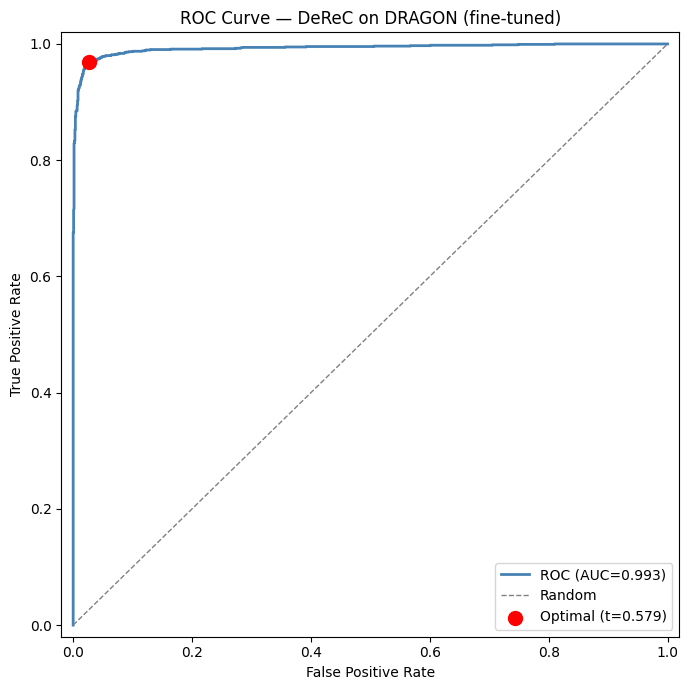

In [15]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Random")
ax.scatter([fpr[best_idx]], [tpr[best_idx]], color="red", s=100, zorder=5,
           label=f"Optimal (t={best_threshold:.3f})")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — DeReC on DRAGON (fine-tuned)")
ax.legend(loc="lower right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()

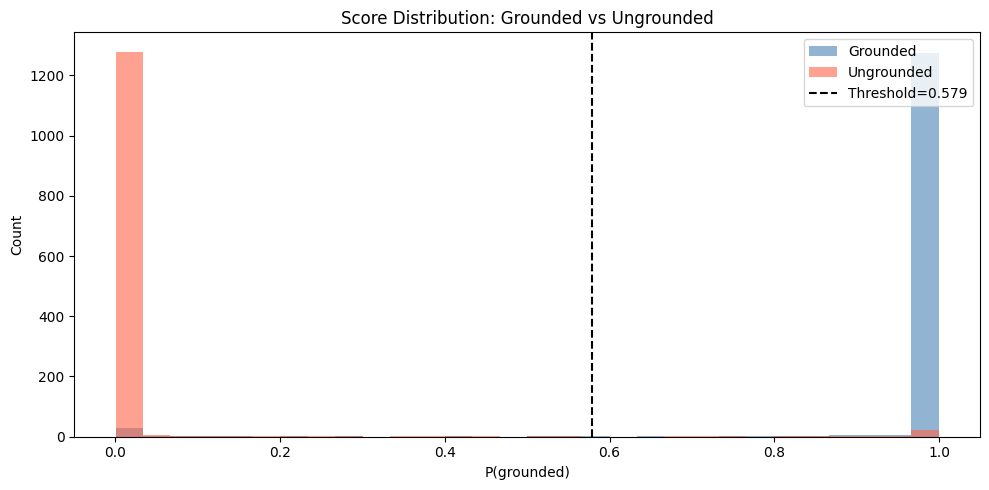

In [16]:
grounded_probs = probs[all_labels == 1]
ungrounded_probs = probs[all_labels == 0]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(grounded_probs, bins=30, alpha=0.6, label="Grounded", color="steelblue")
ax.hist(ungrounded_probs, bins=30, alpha=0.6, label="Ungrounded", color="tomato")
ax.axvline(best_threshold, color="black", linestyle="--",
           label=f"Threshold={best_threshold:.3f}")
ax.set_xlabel("P(grounded)")
ax.set_ylabel("Count")
ax.set_title("Score Distribution: Grounded vs Ungrounded")
ax.legend()
plt.tight_layout()
plt.show()

## Save Results

In [17]:
final_results = {
    "run_id": run_id,
    "best_epoch": pipeline.best_epoch,
    "test_metrics": test_metrics,
    "roc_auc": auc,
    "optimal_threshold": float(best_threshold),
    "config": {
        "classifier_model": CLASSIFIER_MODEL_NAME,
        "dataset": DATASET_NAME,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "epochs": EPOCH_SIZE,
        "seed": SEED,
    },
}

results_path = os.path.join(save_dir, "final_results.json")
with open(results_path, "w") as f:
    json.dump(final_results, f, indent=2)

print(f"Results saved to {results_path}")
print(json.dumps(final_results, indent=2))

Results saved to rag_fact_checking/DEREC/saved_models/dragon_classifier/run_20260315_144302_616bc0d6/final_results.json
{
  "run_id": "20260315_144302_616bc0d6",
  "best_epoch": 9,
  "test_metrics": {
    "accuracy": 0.97,
    "precision": 0.9700002578876586,
    "recall": 0.97,
    "f1": 0.9699999958847731
  },
  "roc_auc": 0.9927561042524006,
  "optimal_threshold": 0.5790086388587952,
  "config": {
    "classifier_model": "ruDeberta",
    "dataset": "DRAGON",
    "batch_size": 8,
    "learning_rate": 5e-06,
    "epochs": 10,
    "seed": 44
  }
}


## Publish to HuggingFace

In [18]:
from huggingface_hub import HfApi

assert HF_TOKEN, "Set HF_TOKEN in the constants cell"

api = HfApi(token=HF_TOKEN)
checkpoint_dir = os.path.join(save_dir, f"epoch_{pipeline.best_epoch}")

api.create_repo(repo_id=HF_MODEL_REPO, exist_ok=True)
api.upload_folder(
    folder_path=checkpoint_dir,
    repo_id=HF_MODEL_REPO,
    repo_type="model",
)
print(f"Uploaded to https://huggingface.co/{HF_MODEL_REPO}")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded to https://huggingface.co/Makson4ic/derec-dragon-ruDeberta
